In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')
from catboost.utils import get_gpu_device_count
print("Available GPUs:", get_gpu_device_count())



Available GPUs: 1


In [2]:
df = pd.read_csv("d:\CBRI_project\project\project\CPCB_Daily_Cleaned 2.csv")

# Create a proper datetime column from Year, Month, Day
df['Timestamp'] = pd.to_datetime(df[['Year','Month','Day']], errors='coerce')

# Drop rows that couldn't be converted (if any)
df.dropna(subset=['Timestamp'], inplace=True)

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Optional: Sort by datetime
df.sort_index(inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

print(df.head())


            PM2.5 (µg/m³)  PM10 (µg/m³)  NO (µg/m³)  NO2 (µg/m³)  NOx (ppb)  \
Timestamp                                                                     
2017-07-01          35.07         59.57        3.42        16.84      11.47   
2017-07-02          40.67        111.65        2.97        15.38      10.60   
2017-07-03          43.01        105.91        3.46        19.63      13.23   
2017-07-04          46.65        123.31        3.22        16.37      11.31   
2017-07-05          49.73        128.29        3.34        17.21      11.86   

            NH3 (µg/m³)  SO2 (µg/m³)  CO (mg/m³)  Ozone (µg/m³)  \
Timestamp                                                         
2017-07-01         4.70        27.11        1.35          66.21   
2017-07-02         3.84        14.22        1.12           9.77   
2017-07-03         4.46        34.07        1.71          13.86   
2017-07-04         4.97        33.52        1.48          15.62   
2017-07-05         4.75        32.45        

In [3]:
import pandas as pd

df = pd.read_csv("d:\CBRI_project\project\project\CPCB_Daily_Cleaned 2.csv")
print(df.columns.tolist())


['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)', 'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'Year', 'Month', 'Day', 'AQI']


In [4]:
feature_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)', 'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'Year', 'Month', 'Day']

target_col = 'AQI'
X = df[feature_cols]
y = df[target_col]


data cleaning lagging and rolling


In [5]:

print("Dataset shape:", df.shape)
import numpy as np

# Missing value check
print("\nColumns with missing values (count > 0):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop unused columns
drop_cols = ["Timestamp", "O Xylene (µg/m³)", "Eth-Benzene (µg/m³)", "MP-Xylene (µg/m³)"]
for c in drop_cols:
    if c in df.columns:
        df = df.drop(columns=[c])

# Ensure target exists and drop rows with missing target
TARGET = "PM2.5 (µg/m³)"
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in CSV.")
df = df.dropna(subset=[TARGET])

# Fill numeric missing values by median
df = df.fillna(df.median(numeric_only=True))
print("\nRemaining missing values:", df.isnull().sum().sum())

# --------------------
# Outlier handling (IQR capping)
# --------------------
def cap_outliers_iqr(series, threshold=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - threshold * IQR, Q3 + threshold * IQR
    return np.clip(series, lower, upper)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)

print("\nCapping outliers in numeric columns...")
for col in num_cols:
    before_outliers = ((df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
                       (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))).sum()
    if before_outliers > 0:
        df[col] = cap_outliers_iqr(df[col])
        print(f"  - {col}: capped {before_outliers} outliers")

# --------------------
# Feature engineering
# --------------------
def create_time_series_features(df_in, target_col, lags=7):
    df = df_in.copy()

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        possible_date_cols = [c for c in df.columns if c.lower() == "date"]
        if possible_date_cols:
            date_col = possible_date_cols[0]
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.set_index(date_col)
        else:
            df.index = pd.date_range(start="2000-01-01", periods=len(df), freq="D")

    idx = df.index

    # Calendar features
    df["hour"] = getattr(idx, "hour", pd.Index([0] * len(idx)))
    df["dayofweek"] = idx.dayofweek
    df["quarter"] = idx.quarter
    df["month"] = idx.month
    df["year"] = idx.year
    df["dayofyear"] = idx.dayofyear
    df["dayofmonth"] = idx.day
    df["weekofyear"] = idx.isocalendar().week.astype(int)

    # Lag features
    for lag in range(1, lags + 1):
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    # Rolling windows (shift before rolling to avoid leakage)
    df[f"{target_col}_roll_mean_7"] = df[target_col].shift(1).rolling(window=7, min_periods=1).mean()
    df[f"{target_col}_roll_std_7"] = df[target_col].shift(1).rolling(window=7, min_periods=1).std().fillna(0)
    df[f"{target_col}_roll_mean_30"] = df[target_col].shift(1).rolling(window=30, min_periods=1).mean()

    # Exponential Moving Average
    df[f"{target_col}_ema_7"] = df[target_col].shift(1).ewm(span=7, adjust=False).mean()

    # Drop rows with NaNs from lags/rolling
    df = df.dropna()
    return df

# Apply feature engineering
df_features = create_time_series_features(df, TARGET, lags=7)
print("After feature engineering, rows:", df_features.shape[0])


Dataset shape: (2010, 29)

Columns with missing values (count > 0):
O Xylene (µg/m³)       2010
Eth-Benzene (µg/m³)    2010
MP-Xylene (µg/m³)      2010
dtype: int64

Remaining missing values: 0

Capping outliers in numeric columns...
  - PM10 (µg/m³): capped 77 outliers
  - NO (µg/m³): capped 82 outliers
  - NO2 (µg/m³): capped 60 outliers
  - NOx (ppb): capped 79 outliers
  - NH3 (µg/m³): capped 103 outliers
  - SO2 (µg/m³): capped 104 outliers
  - CO (mg/m³): capped 62 outliers
  - Ozone (µg/m³): capped 180 outliers
  - Benzene (µg/m³): capped 26 outliers
  - Toluene (µg/m³): capped 79 outliers
  - Xylene (µg/m³): capped 93 outliers
  - AT (°C): capped 43 outliers
  - RH (%): capped 97 outliers
  - WS (m/s): capped 12 outliers
  - WD (deg): capped 47 outliers
  - RF (mm): capped 375 outliers
  - TOT-RF (mm): capped 372 outliers
  - SR (W/mt2): capped 77 outliers
  - BP (mmHg): capped 111 outliers
  - VWS (m/s): capped 14 outliers
  - AQI: capped 134 outliers
After feature engineering

In [6]:
split_index = int(len(df)*0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [7]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    l2_leaf_reg=5,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Predictions
y_pred_cat = cat_model.predict(X_test)

# Evaluation
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)
print(f"CatBoost RMSE: {rmse_cat:.2f}")
print(f"CatBoost R2: {r2_cat:.2f}")

0:	learn: 55.7912927	test: 48.8763305	best: 48.8763305 (0)	total: 121ms	remaining: 2m 1s
100:	learn: 19.1278195	test: 18.7322784	best: 18.7322784 (100)	total: 375ms	remaining: 3.34s
200:	learn: 16.7938820	test: 18.4281216	best: 18.4249514 (199)	total: 562ms	remaining: 2.23s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 18.3941961
bestIteration = 206

Shrink model to first 207 iterations.
CatBoost RMSE: 18.39
CatBoost R2: 0.87


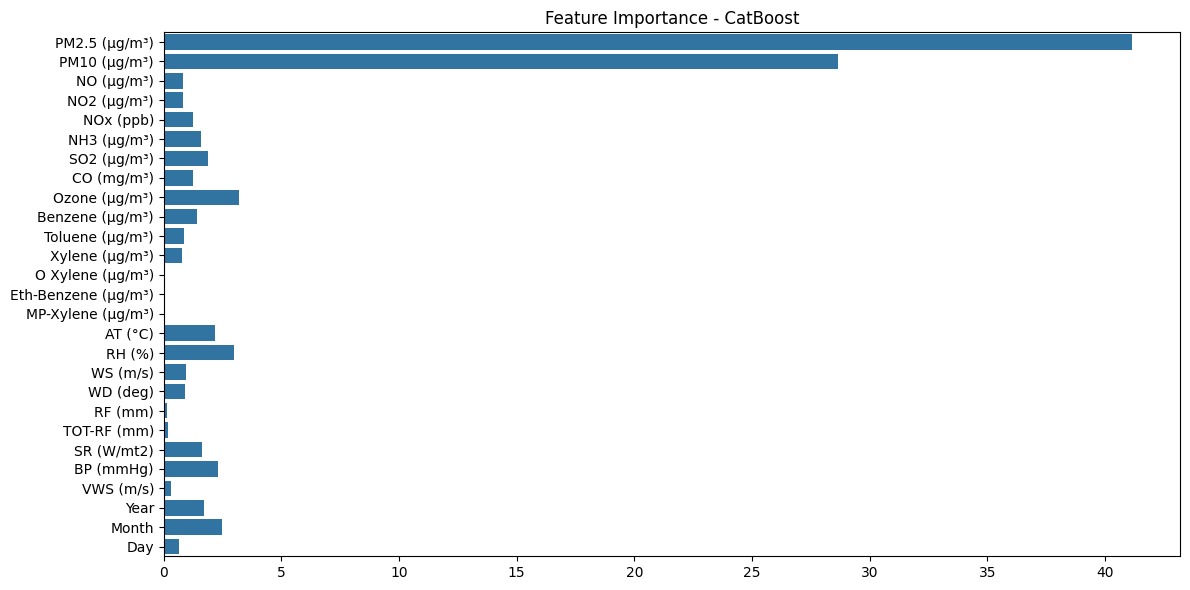

In [8]:
# Feature importance
plt.figure(figsize=(12,6))
sns.barplot(x=cat_model.get_feature_importance(), y=feature_cols)
plt.title("Feature Importance - CatBoost")
plt.tight_layout()
plt.show()


In [9]:
aqi_series = df['AQI']

# Train/test split (same as CatBoost)
split_index = int(len(aqi_series)*0.8)
train_aqi = aqi_series[:split_index]
test_aqi = aqi_series[split_index:]

In [10]:
# Fit ARIMA model (you can tune order=(p,d,q) as needed)
arima_model = ARIMA(train_aqi, order=(8,1,0))
arima_fit = arima_model.fit()

# Forecast
forecast_arima = arima_fit.forecast(steps=len(test_aqi))

In [11]:
rmse_arima = np.sqrt(mean_squared_error(test_aqi, forecast_arima))
r2_arima = r2_score(test_aqi, forecast_arima)
print(f"ARIMA RMSE: {rmse_arima:.2f}")
print(f"ARIMA R2: {r2_arima:.2f}")


ARIMA RMSE: 67.13
ARIMA R2: -1.11


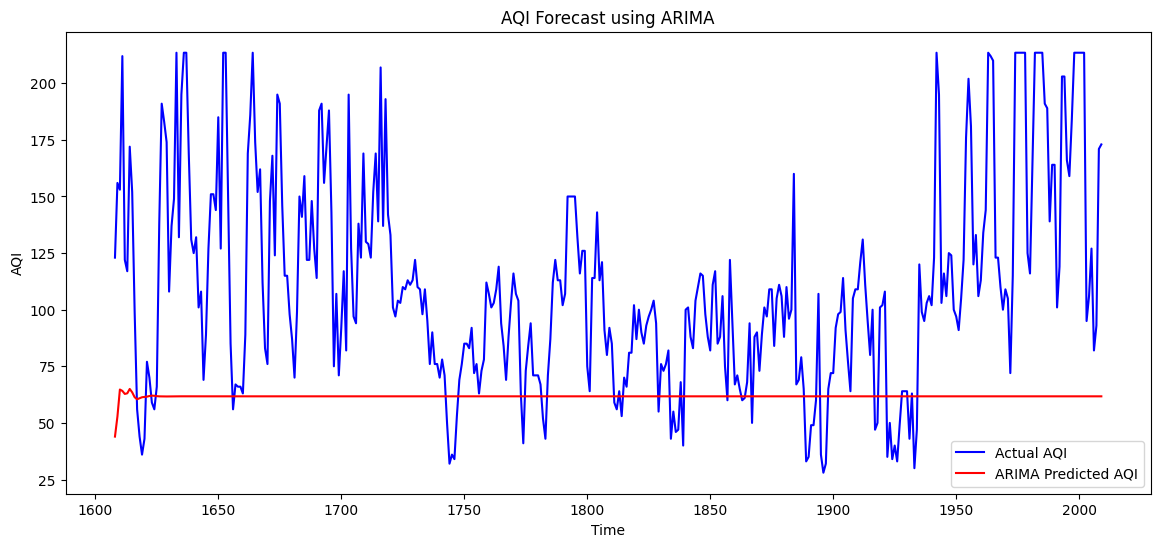

In [12]:

# Plot Actual vs ARIMA Forecast
plt.figure(figsize=(14,6))
plt.plot(test_aqi.index, test_aqi, label='Actual AQI', color='blue')
plt.plot(test_aqi.index, forecast_arima, label='ARIMA Predicted AQI', color='red')
plt.title("AQI Forecast using ARIMA")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.show()

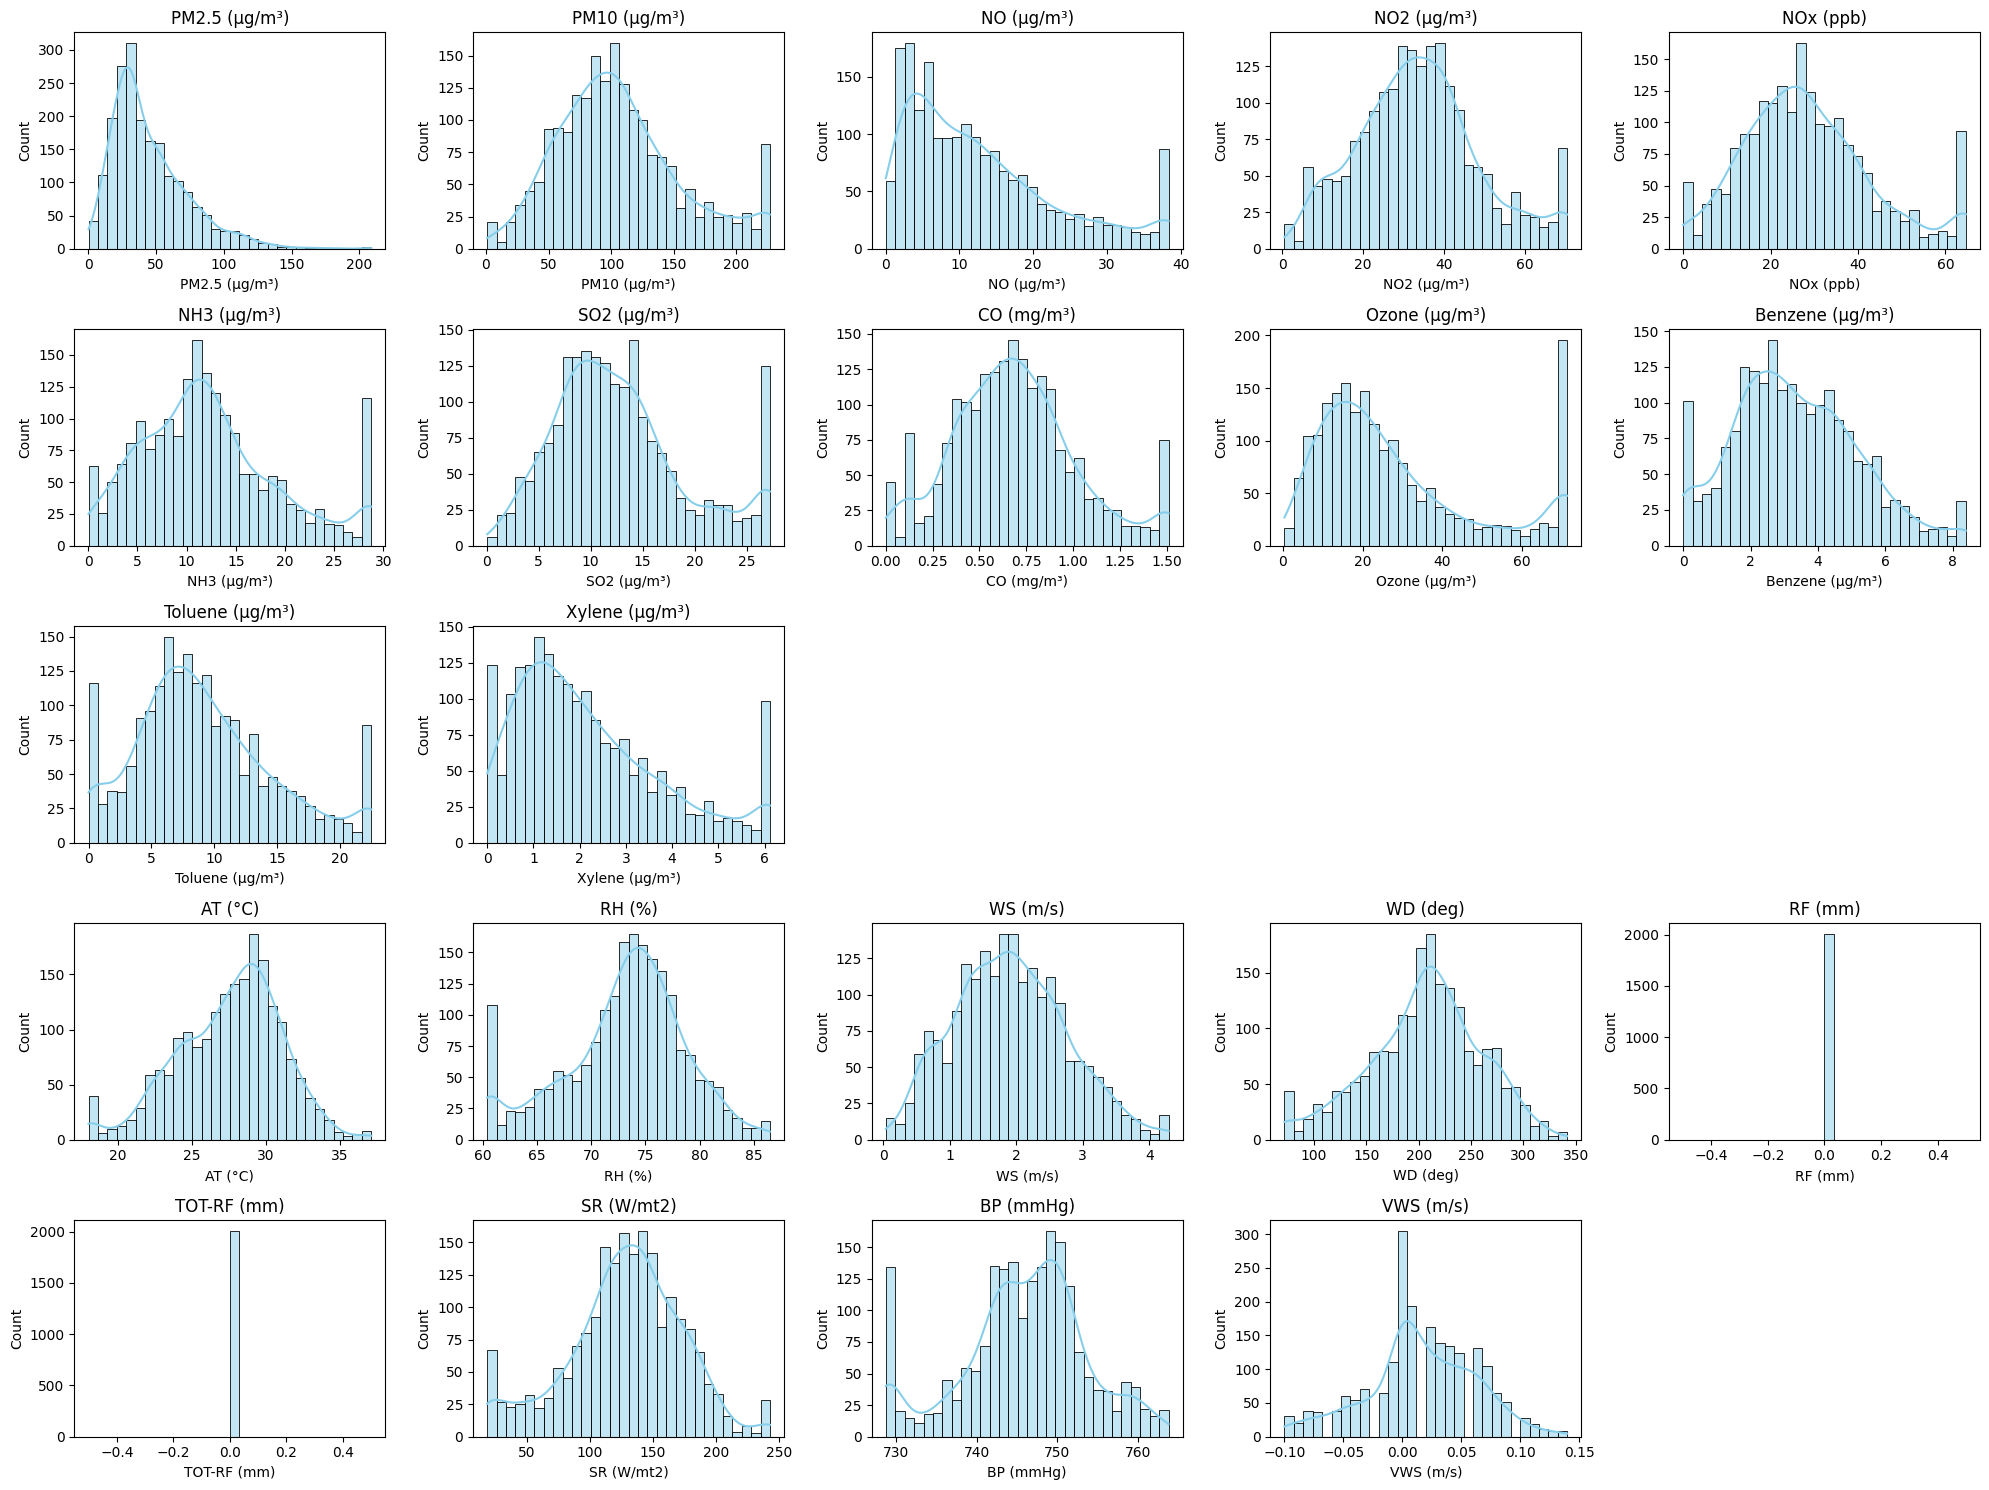

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)',
              'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
              'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)', 'O Xylene (µg/m³)',
              'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)',
              'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)']

plt.figure(figsize=(20,15))
for i, col in enumerate(pollutants):
    if col not in df.columns:
        continue
    plt.subplot(5,5,i+1)  # Adjust grid to fit 24 variables
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()


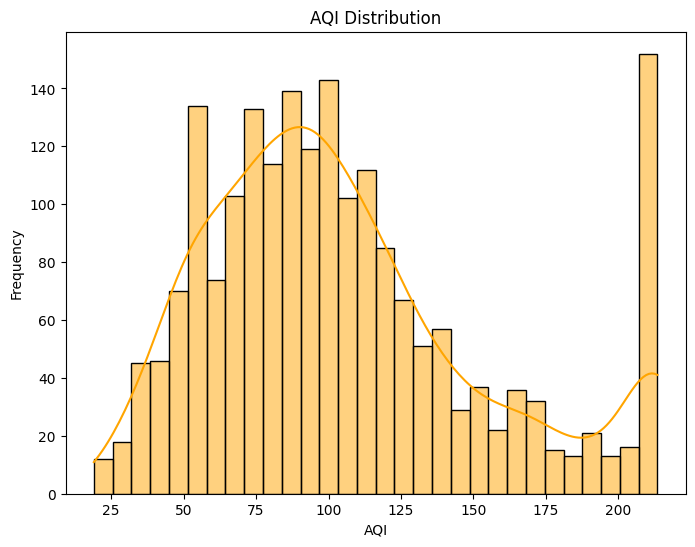

In [14]:
# --------------------------
# Step 4: Optional: AQI Distribution Histogram
# --------------------------
plt.figure(figsize=(8,6))
sns.histplot(df['AQI'], bins=30, kde=True, color='orange')
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

## Hybrid Model

In [15]:
target_col = "PM2.5 (µg/m³)"
feature_cols = [c for c in df.columns if c != target_col] 
X = df[feature_cols]

y = df[target_col]

# Train/test split (time-based)
split_index = int(len(df)*0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# CatBoost model
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test))



0:	learn: 26.6005540	test: 23.7289005	best: 23.7289005 (0)	total: 3.41ms	remaining: 3.41s
100:	learn: 5.8422761	test: 8.5213978	best: 8.4089451 (82)	total: 209ms	remaining: 1.86s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.408945126
bestIteration = 82

Shrink model to first 83 iterations.


In [16]:
# CatBoost predictions
cb_pred_train = cb_model.predict(X_train)
cb_pred_test = cb_model.predict(X_test)

# Evaluate CatBoost
rmse_cb = np.sqrt(mean_squared_error(y_test, cb_pred_test))
r2_cb = r2_score(y_test, cb_pred_test)
print(f"CatBoost RMSE: {rmse_cb:.2f}")
print(f"CatBoost R2: {r2_cb:.2f}")

# --------------------------
# Step 3: Compute Residuals
# --------------------------
residuals = y_train - cb_pred_train

# --------------------------
# Step 4: ARIMA on Residuals
# --------------------------
# Fit ARIMA on residuals
arima_model = ARIMA(residuals, order=(5,1,0))
arima_fit = arima_model.fit()

# Forecast residuals for test period
arima_residual_forecast = arima_fit.forecast(steps=len(y_test))

CatBoost RMSE: 8.41
CatBoost R2: 0.89


Hybrid RMSE: 8.40
Hybrid R2: 0.89


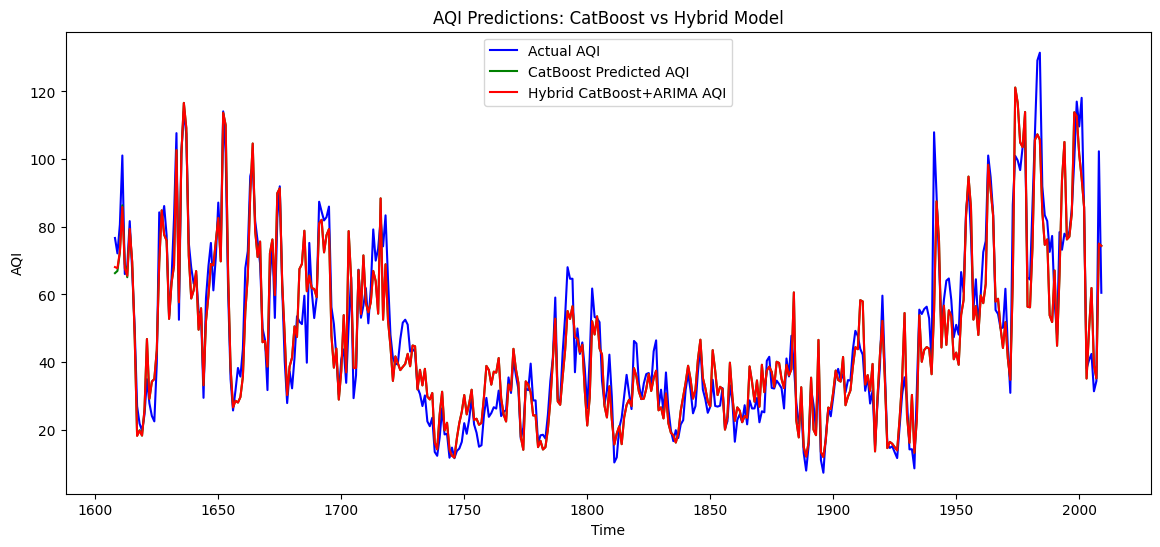

In [17]:

# Step 5: Hybrid Prediction

hybrid_pred = cb_pred_test + arima_residual_forecast

# Evaluate Hybrid Model
rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_pred))
r2_hybrid = r2_score(y_test, hybrid_pred)
print(f"Hybrid RMSE: {rmse_hybrid:.2f}")
print(f"Hybrid R2: {r2_hybrid:.2f}")


# Step 6: Plot Results

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Actual AQI', color='blue')
plt.plot(y_test.index, cb_pred_test, label='CatBoost Predicted AQI', color='green')
plt.plot(y_test.index, hybrid_pred, label='Hybrid CatBoost+ARIMA AQI', color='red')
plt.title("AQI Predictions: CatBoost vs Hybrid Model")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.show()



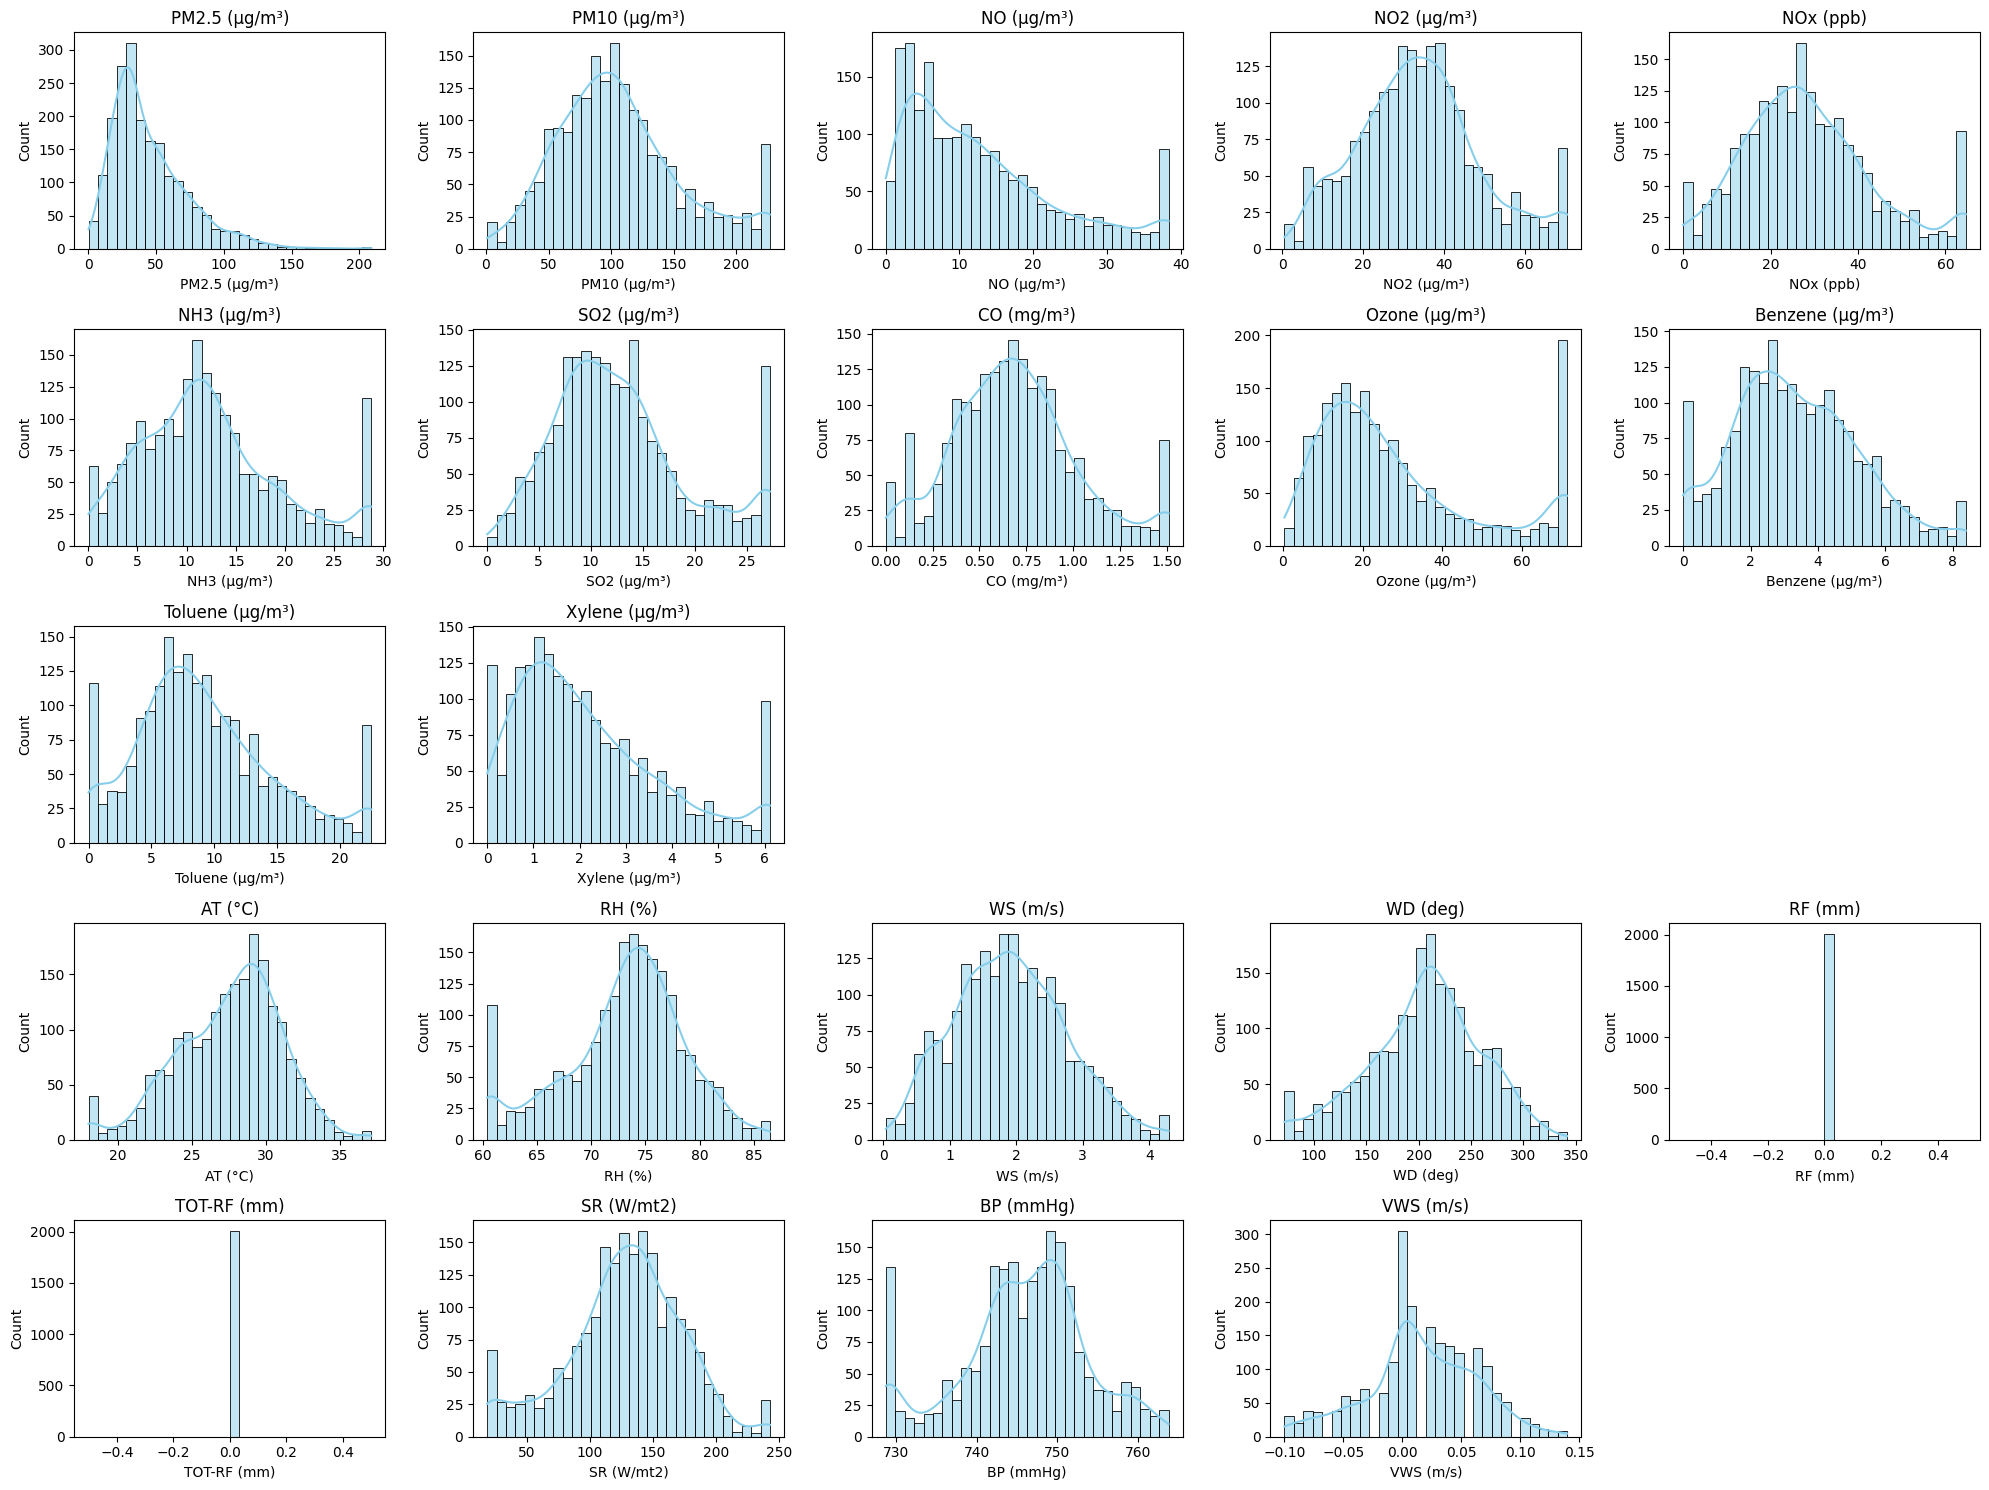

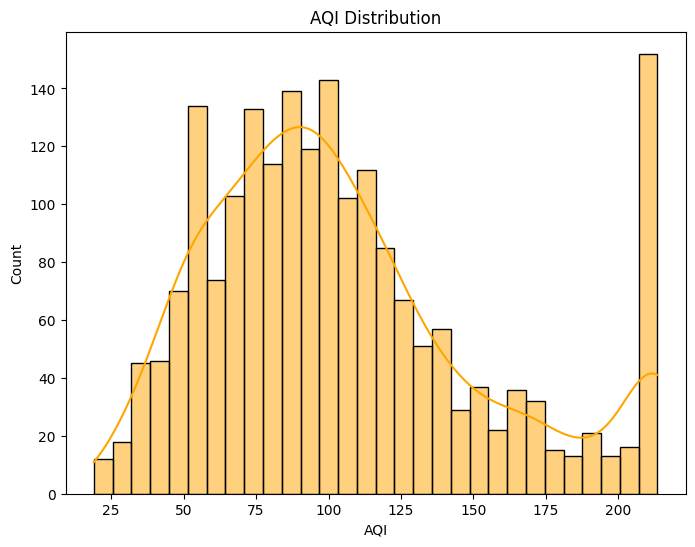

In [18]:

# Step 7: Histograms (Pollutants)

pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)',
              'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
              'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)', 'O Xylene (µg/m³)',
              'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)',
              'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)']

plt.figure(figsize=(20,15))
for i, col in enumerate(pollutants):
    if col not in df.columns:
        continue
    plt.subplot(5,5,i+1)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

# Optional: AQI histogram
plt.figure(figsize=(8,6))
sns.histplot(df['AQI'], bins=30, kde=True, color='orange')
plt.title("AQI Distribution")
plt.show()

In [19]:

# Train tuned ARIMA (2,1,2)

arima_model = ARIMA(y_train, order=(2,1,2))
arima_fit = arima_model.fit()

# Forecast on test set
arima_pred_test = arima_fit.forecast(steps=len(y_test))


# CatBoost predictions (already trained earlier)

cb_pred_test = cb_model.predict(X_test)


# Hybrid model: CatBoost + ARIMA residual correction

residuals_train = y_train - cb_model.predict(X_train)

# Fit ARIMA on residuals instead of raw series
resid_arima_model = ARIMA(residuals_train, order=(2,1,2))
resid_arima_fit = resid_arima_model.fit()

resid_forecast = resid_arima_fit.forecast(steps=len(y_test))
hybrid_pred = cb_pred_test + resid_forecast


# Evaluate all models

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<8} -> RMSE: {rmse:.2f}, R2: {r2:.2f}")
    return rmse, r2

evaluate(y_test, arima_pred_test, "ARIMA")
evaluate(y_test, cb_pred_test, "CatBoost")
evaluate(y_test, hybrid_pred, "Hybrid")


ARIMA    -> RMSE: 26.80, R2: -0.10
CatBoost -> RMSE: 8.41, R2: 0.89
Hybrid   -> RMSE: 8.40, R2: 0.89


(8.399121611479009, 0.8915767654838838)

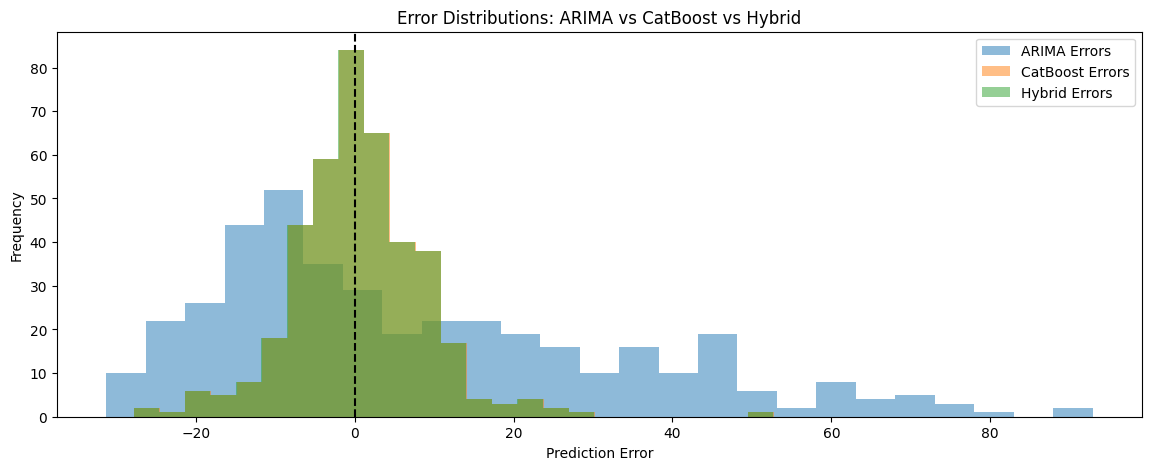

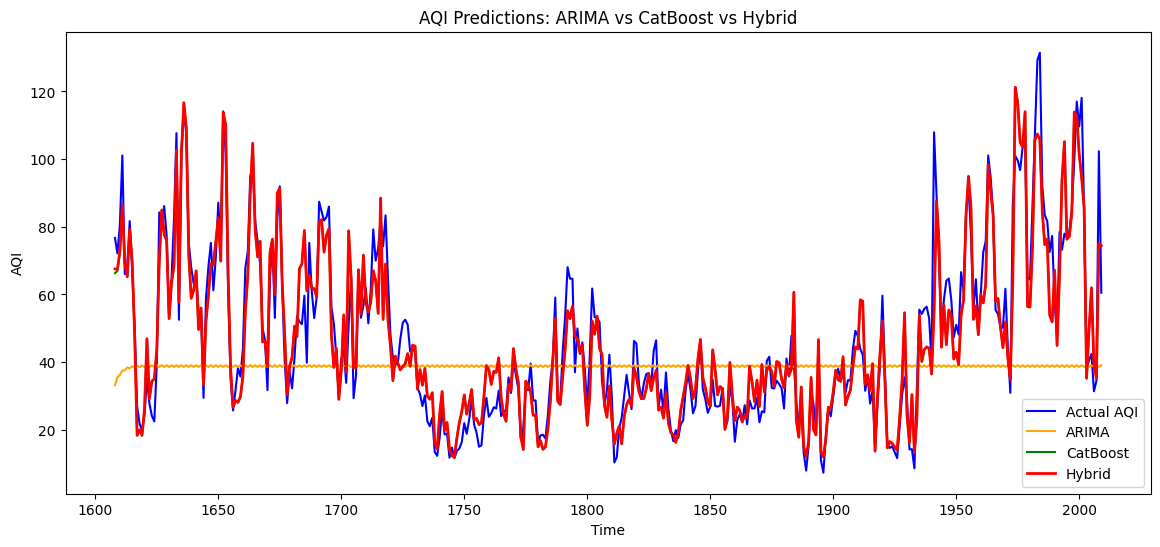

In [20]:

# Step 5: Error Histograms

errors_arima  = y_test - arima_pred_test
errors_cb     = y_test - cb_pred_test
errors_hybrid = y_test - hybrid_pred

plt.figure(figsize=(14,5))
plt.hist(errors_arima, bins=25, alpha=0.5, label="ARIMA Errors")
plt.hist(errors_cb, bins=25, alpha=0.5, label="CatBoost Errors")
plt.hist(errors_hybrid, bins=25, alpha=0.5, label="Hybrid Errors")
plt.axvline(0, color="black", linestyle="--")
plt.title("Error Distributions: ARIMA vs CatBoost vs Hybrid")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# Step 6: Prediction Curves

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="Actual AQI", color="blue")
plt.plot(y_test.index, arima_pred_test, label="ARIMA", color="orange")
plt.plot(y_test.index, cb_pred_test, label="CatBoost", color="green")
plt.plot(y_test.index, hybrid_pred, label="Hybrid", color="red", linewidth=2)
plt.title("AQI Predictions: ARIMA vs CatBoost vs Hybrid")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_squared_error, r2_score


errors_arima = y_test - arima_pred_test
errors_cb = y_test - cb_pred_test
errors_hybrid = y_test - hybrid_pred

rmse_arima = np.sqrt(mean_squared_error(y_test, arima_pred_test))
r2_arima = r2_score(y_test, arima_pred_test)

rmse_cb = np.sqrt(mean_squared_error(y_test, cb_pred_test))
r2_cb = r2_score(y_test, cb_pred_test)

rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_pred))
r2_hybrid = r2_score(y_test, hybrid_pred)

print(f"ARIMA   -> RMSE: {rmse_arima:.2f}, R2: {r2_arima:.2f}")
print(f"CatBoost-> RMSE: {rmse_cb:.2f}, R2: {r2_cb:.2f}")
print(f"Hybrid  -> RMSE: {rmse_hybrid:.2f}, R2: {r2_hybrid:.2f}")

ARIMA   -> RMSE: 26.80, R2: -0.10
CatBoost-> RMSE: 8.41, R2: 0.89
Hybrid  -> RMSE: 8.40, R2: 0.89


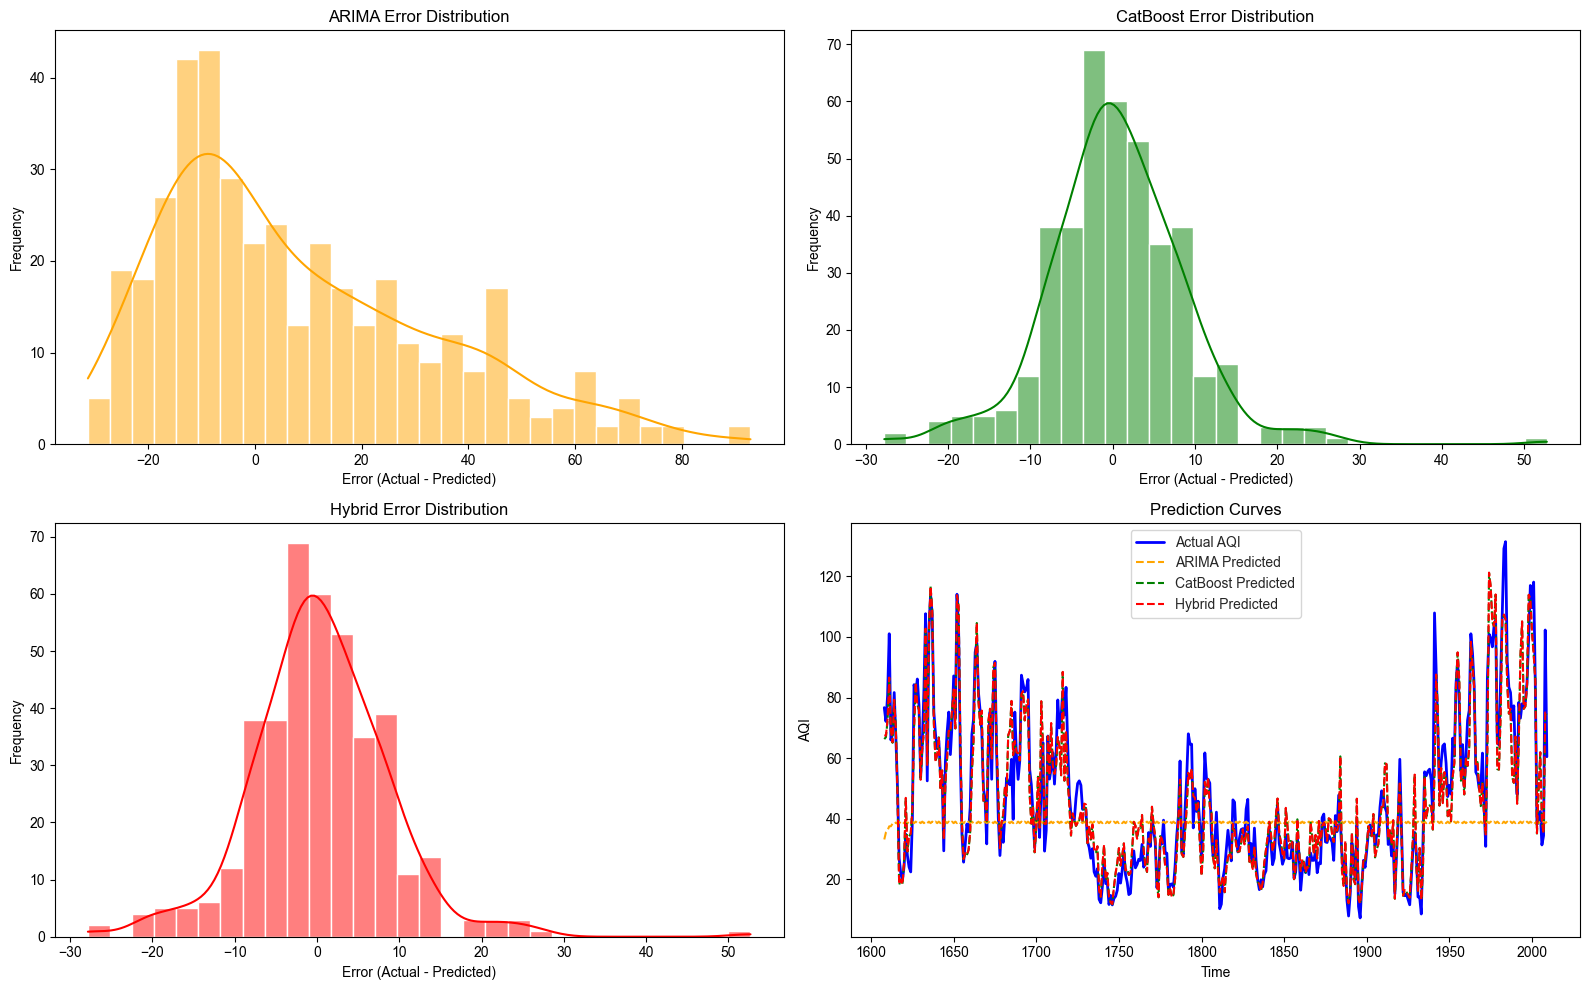

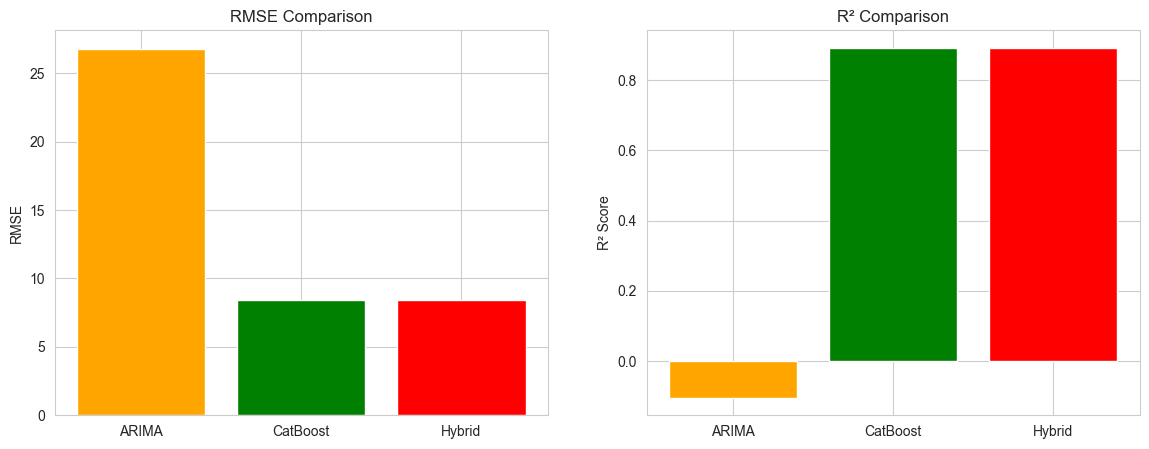

In [22]:

# Step 2: Visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.set_style("whitegrid")

# Error distributions
sns.histplot(errors_arima, bins=30, kde=True, color="orange", ax=axes[0,0])
axes[0,0].set_title("ARIMA Error Distribution")
axes[0,0].set_xlabel("Error (Actual - Predicted)")
axes[0,0].set_ylabel("Frequency")

sns.histplot(errors_cb, bins=30, kde=True, color="green", ax=axes[0,1])
axes[0,1].set_title("CatBoost Error Distribution")
axes[0,1].set_xlabel("Error (Actual - Predicted)")
axes[0,1].set_ylabel("Frequency")

sns.histplot(errors_hybrid, bins=30, kde=True, color="red", ax=axes[1,0])
axes[1,0].set_title("Hybrid Error Distribution")
axes[1,0].set_xlabel("Error (Actual - Predicted)")
axes[1,0].set_ylabel("Frequency")

# Prediction curves
axes[1,1].plot(y_test.index, y_test, label="Actual AQI", color="blue", linewidth=2)
axes[1,1].plot(y_test.index, arima_pred_test, label="ARIMA Predicted", color="orange", linestyle="--")
axes[1,1].plot(y_test.index, cb_pred_test, label="CatBoost Predicted", color="green", linestyle="--")
axes[1,1].plot(y_test.index, hybrid_pred, label="Hybrid Predicted", color="red", linestyle="--")
axes[1,1].set_title("Prediction Curves")
axes[1,1].set_xlabel("Time")
axes[1,1].set_ylabel("AQI")
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Step 3: Metrics Bar Chart

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# RMSE Bar Plot
ax[0].bar(["ARIMA","CatBoost","Hybrid"], [rmse_arima, rmse_cb, rmse_hybrid], color=["orange","green","red"])
ax[0].set_title("RMSE Comparison")
ax[0].set_ylabel("RMSE")

# R² Bar Plot
ax[1].bar(["ARIMA","CatBoost","Hybrid"], [r2_arima, r2_cb, r2_hybrid], color=["orange","green","red"])
ax[1].set_title("R² Comparison")
ax[1].set_ylabel("R² Score")

plt.show()

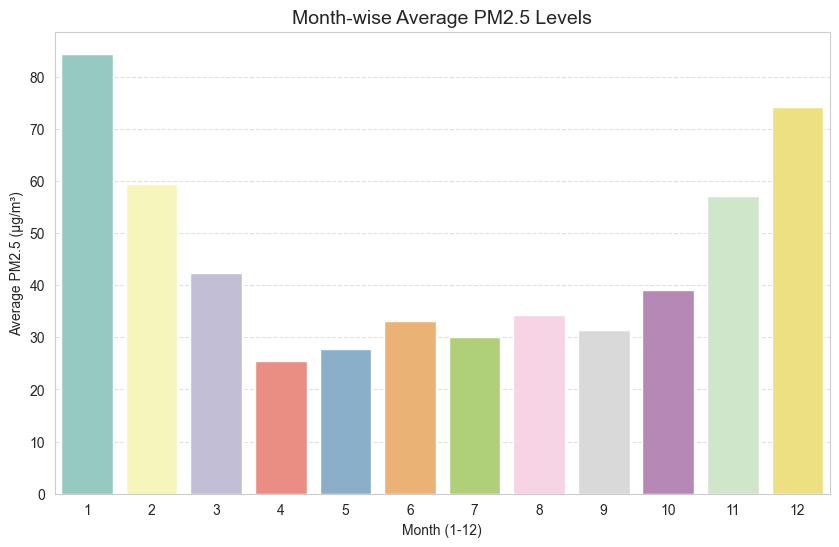

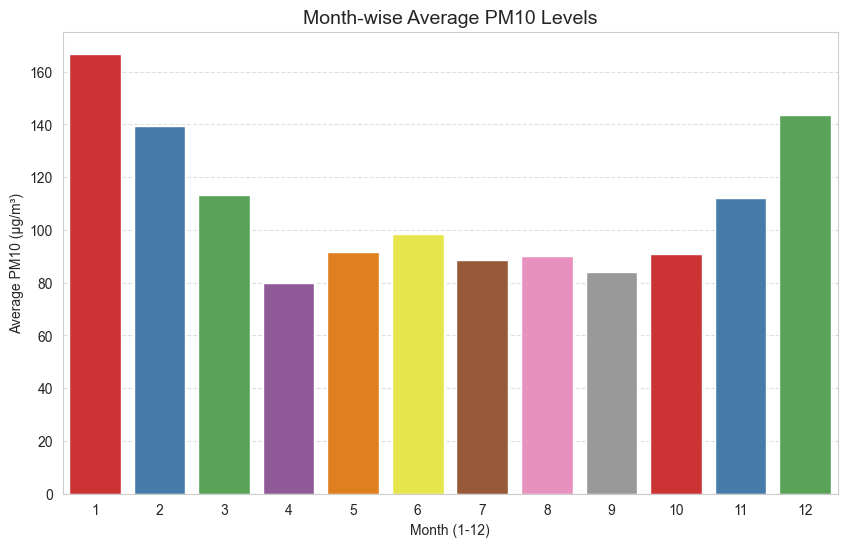

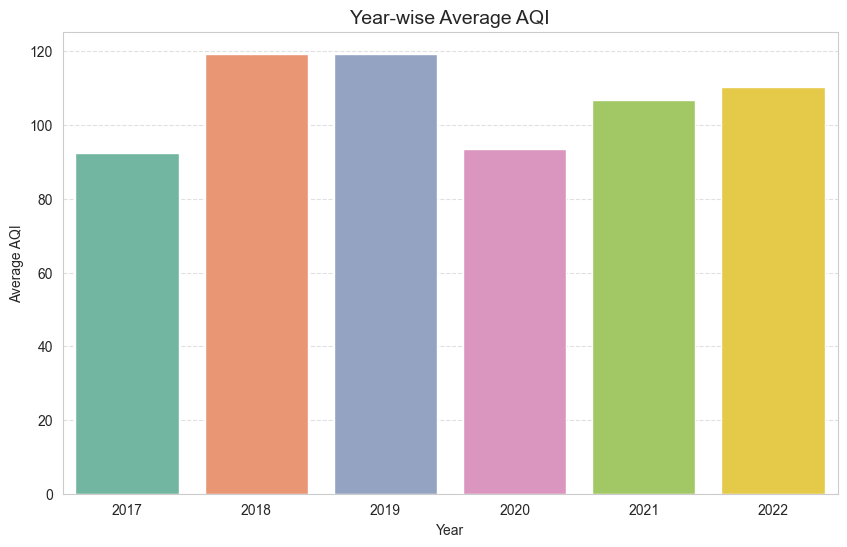

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read dataset
df = pd.read_csv("d:/CBRI_project/project/project/CPCB_Daily_Cleaned 2.csv")

# Create a proper datetime column
df['Timestamp'] = pd.to_datetime(df[['Year','Month','Day']], errors='coerce')

# Drop invalid dates
df.dropna(subset=['Timestamp'], inplace=True)

# Set index
df.set_index('Timestamp', inplace=True)
df.sort_index(inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

#   Month-wise Average PM2.5 
pm25_monthwise = df.groupby('Month')['PM2.5 (µg/m³)'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Month', y='PM2.5 (µg/m³)', data=pm25_monthwise, palette="Set3")
plt.title("Month-wise Average PM2.5 Levels", fontsize=14)
plt.xlabel("Month (1-12)")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# Month-wise Average PM10 
pm10_monthwise = df.groupby('Month')['PM10 (µg/m³)'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Month', y='PM10 (µg/m³)', data=pm10_monthwise, palette="Set1")

plt.title("Month-wise Average PM10 Levels", fontsize=14)
plt.xlabel("Month (1-12)")
plt.ylabel("Average PM10 (µg/m³)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# Year-wise Average AQI
yearwise = df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10,6))
#sns.barplot(x='Year', y='AQI', data=yearwise, palette="coolwarm")
sns.barplot(x='Year', y='AQI', data=yearwise, palette="Set2")
plt.title("Year-wise Average AQI", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [24]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# -----------------------------
# Step 1: Fit SARIMA
# -----------------------------
sarima_model = SARIMAX(df[TARGET_COL], order=(2,1,2), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)

# In-sample SARIMA predictions
df['sarima_pred'] = sarima_fit.predict(start=0, end=len(df)-1)

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
def add_lag_rolling(df, col, lags=[1,2,3,6,12,24,48], rolls=[3,7,14,30]):
    out = df.copy()
    for l in lags:
        out[f"lag_{l}"] = out[col].shift(l)
    for r in rolls:
        out[f"roll_mean_{r}"] = out[col].shift(1).rolling(r).mean()
        out[f"roll_std_{r}"]  = out[col].shift(1).rolling(r).std()
        out[f"roll_min_{r}"]  = out[col].shift(1).rolling(r).min()
        out[f"roll_max_{r}"]  = out[col].shift(1).rolling(r).max()
    # time-based features if datetime index
    if isinstance(out.index, pd.DatetimeIndex):
        out["month"] = out.index.month
        out["dayofweek"] = out.index.dayofweek
        out["hour"] = out.index.hour
    return out

feat = add_lag_rolling(df, TARGET_COL)

# Add SARIMA prediction as feature
feat['sarima_pred'] = df['sarima_pred']

# Drop missing rows
feat = feat.dropna()

X = feat.drop(columns=[TARGET_COL])
y = feat[TARGET_COL]

# -----------------------------
# Step 3: Train/Test Split (time-based)
# -----------------------------
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# -----------------------------
# Step 4: Train Base Models
# -----------------------------
# CatBoost
cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.02,
    depth=12,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=1000,
    early_stopping_rounds=300
)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    max_features="sqrt"
)
rf_model.fit(X_train, y_train)

# XGBoost (extra boost)
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=500)

# -----------------------------
# Step 5: Stacking (Meta Model)
# -----------------------------
# First-level predictions
cat_pred_train = cat_model.predict(X_train)
rf_pred_train = rf_model.predict(X_train)
xgb_pred_train = xgb_model.predict(X_train)

cat_pred_test = cat_model.predict(X_test)
rf_pred_test = rf_model.predict(X_test)
xgb_pred_test = xgb_model.predict(X_test)

# Create meta dataset
stacked_X_train = np.column_stack((cat_pred_train, rf_pred_train, xgb_pred_train))
stacked_X_test = np.column_stack((cat_pred_test, rf_pred_test, xgb_pred_test))

# Meta model (Ridge Regression with scaling for stability)
meta_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
meta_model.fit(stacked_X_train, y_train)

# Final stacked predictions
final_pred = meta_model.predict(stacked_X_test)

# -----------------------------
# Step 6: Evaluation
# -----------------------------
mae = mean_absolute_error(y_test, final_pred)
mse = mean_squared_error(y_test, final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


NameError: name 'TARGET_COL' is not defined